In [181]:
import numpy as np
from hmmlearn.hmm import GaussianHMM
from hmmlearn.hmm import CategoricalHMM
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [182]:
observations = np.load('outcomes_array.npy', allow_pickle=True)


In [183]:
# Convert labels to integer format
encoder = LabelEncoder()
obs_encoded = encoder.fit_transform(observations)

# Reshape to (n_samples, 1) as required by CategoricalHMM
X = obs_encoded.reshape(-1, 1)


In [184]:
# model = CategoricalHMM(n_components=3, n_features=np.unique(X).size, n_iter=1000)
# model.fit(X)

best_model = None
best_score = -np.inf  # Initialize with a very low score

for _ in range(1000):  # Train multiple times
    model = CategoricalHMM(n_components=2, n_features=np.unique(X).size, random_state=None, n_iter=100)
    model.fit(X)
    log_prob = model.score(X)  # Get model likelihood
    
    if log_prob > best_score:  # Keep best model
        best_score = log_prob
        best_model = model

print("Best Model Score:", best_score)

# Print the estimated parameters
print("Estimated Start Probabilities:\n", model.startprob_)
print("Estimated Transition Matrix:\n", model.transmat_)
print("Estimated Emission Probabilities:\n", model.emissionprob_)


Best Model Score: -570.5029326963838
Estimated Start Probabilities:
 [6.06342301e-23 1.00000000e+00]
Estimated Transition Matrix:
 [[0.99257319 0.00742681]
 [0.00638901 0.99361099]]
Estimated Emission Probabilities:
 [[0.26003622 0.49454644 0.24541734]
 [0.76449449 0.20710544 0.02840006]]


In [185]:
# Use Viterbi algorithm to find the most probable sequence of hidden states
log_prob, hidden_states = model.decode(X, algorithm="viterbi")

print("Most Likely Hidden States:", hidden_states)


Most Likely Hidden States: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

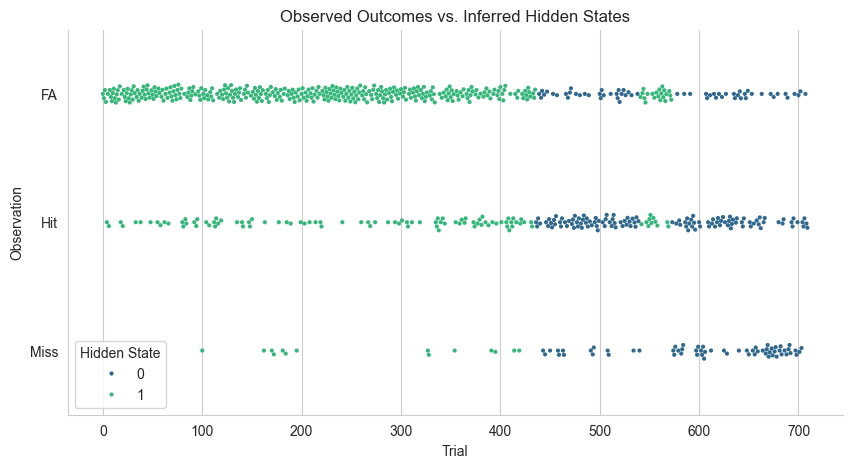

In [186]:
df = pd.DataFrame({
    "Trial": np.arange(len(X)),
    "Observation": encoder.inverse_transform(X.ravel()),  # Convert back to categorical labels
    "Hidden State": hidden_states
})

# Step 5: Plot with Seaborn
plt.figure(figsize=(10, 5))

# Swarmplot for observed behaviors
sns.swarmplot(x="Trial", y="Observation", data=df, hue="Hidden State", palette="viridis", size=3)

sns.despine()

# Customize plot
plt.title("Observed Outcomes vs. Inferred Hidden States")
plt.show()